# Notebook 04 - Behavioral Clustering

Grouping students into behavioral profiles with K-Means. The plan is the usual
one: scale the behavioral features, sweep k with the elbow and silhouette, pick
a final k value, and then read the cluster centres to see what each group actually is and
name them.



Features come from the preprocessor's cluster matrix on the **training
split only**, so nothing from the held-out test split leaks into the scaler or
the centroids.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "ml" / "config.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ml import config
from ml.clustering import StudentProfileClusterer, load_cluster_training_features

sns.set_theme(style="whitegrid")

features = load_cluster_training_features()
features.shape

(960, 14)

Fit and sweep k from 2 to 10. The clusterer keeps the inertia and
silhouette for every k so I can look at both.

In [2]:
clusterer = StudentProfileClusterer().fit(features)
pd.Series(clusterer.silhouette_scores_, name="silhouette").round(3)

2     0.114
3     0.093
4     0.086
5     0.078
6     0.075
7     0.074
8     0.073
9     0.071
10    0.071
Name: silhouette, dtype: float64

Silhouette peaks at k=2 and falls off after that, and even the best score
is only around 0.11. So this data doesn't break into clean, well-separated
groups. I'm using k=4 regardless: two clusters is too blunt to act on, and the
four-way split gives profiles that are clearly different from each other and map
onto distinct interventions. That makes k=4 a deliberate choice for useful
granularity as we have to bring granularity instead of discreetness for two feature set. The silhouette plot
marks both the peak (k=2) and the chosen k (4) so the trade-off is visible.

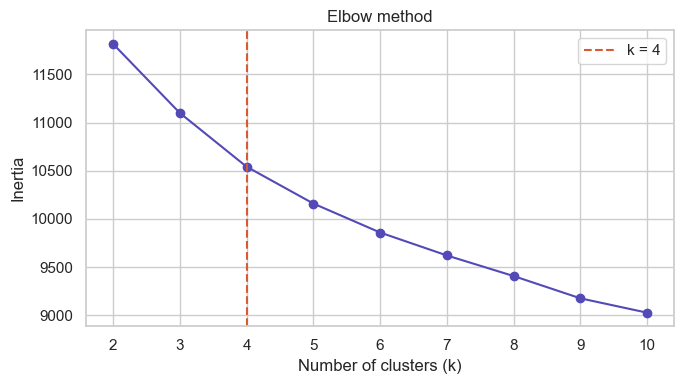

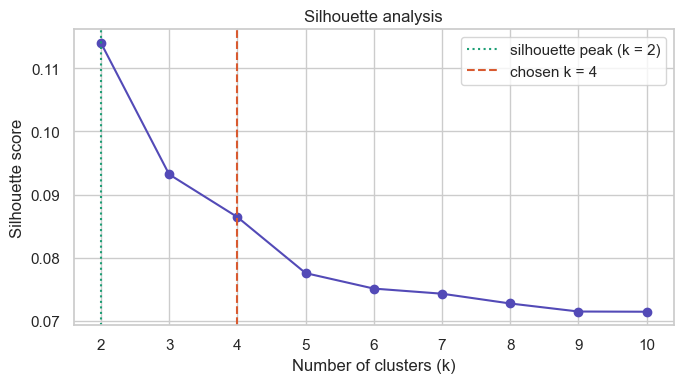

In [3]:
clusterer.plot_elbow(config.PLOTS_DIR / "clustering_elbow.png")
clusterer.plot_silhouette(config.PLOTS_DIR / "clustering_silhouette.png");

Cluster centres, in ordinal-code space (0 is the lowest band of each
feature). The raw means are a bit hard to read across features on different
scales, so the z-scored heatmap underneath is what I actually use to interpret
them.

In [4]:
profiles = clusterer.get_cluster_profiles()
profiles.T

cluster,0,1,2,3
study_hours_daily,0.522,0.711,1.353,0.638
study_consistency,0.553,1.784,0.996,0.739
daily_productivity,2.114,2.439,3.836,2.422
focus_duration,0.781,0.777,1.310,0.794
revision_frequency,0.868,1.056,1.694,1.060
screen_time_non_study,1.487,1.525,1.138,1.538
procrastination_level,1.728,0.654,1.440,1.618
stress_level,2.482,3.179,2.961,4.121
sleep_hours,1.382,1.150,1.159,0.704
energy_level,3.890,3.425,3.409,1.995


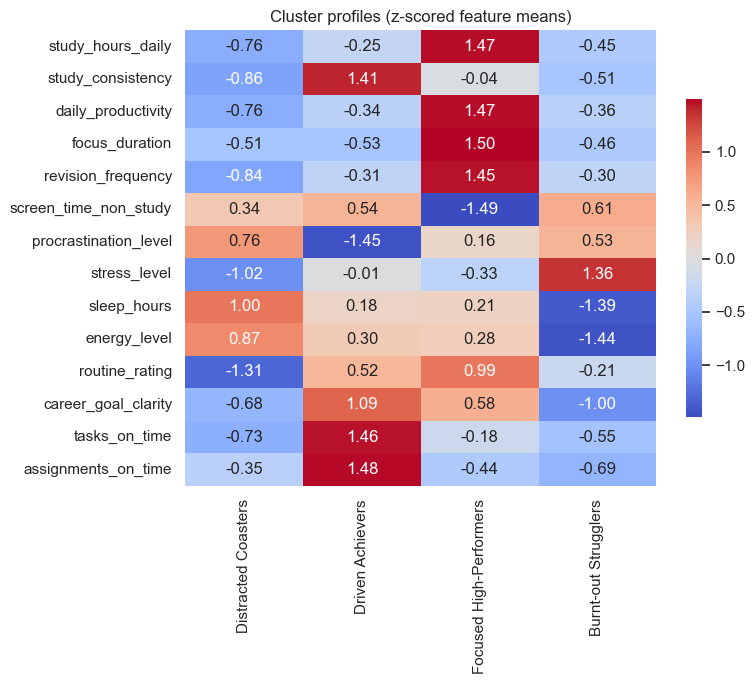

In [5]:
feat_cols = [c for c in profiles.columns if c != "size"]
z = ((profiles[feat_cols] - profiles[feat_cols].mean()) / profiles[feat_cols].std()).T
z.columns = [config.CLUSTER_NAMES[c] for c in z.columns]

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(z, annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Cluster profiles (z-scored feature means)")
fig.tight_layout()
fig.savefig(config.PLOTS_DIR / "clustering_profile_heatmap.png", dpi=120, bbox_inches="tight")

Reading the heatmap, the four groups are:

- **Driven Achievers** (cluster 1): top of the table on study consistency,
  punctuality, and assignments, lowest procrastination, clearest career goals.
  The organised, on-track students.
- **Focused High-Performers** (cluster 2): highest study hours, focus duration,
  productivity, and revision, and the lowest screen time. Intense, heads-down
  workers.
- **Distracted Coasters** (cluster 0): well rested and the least stressed, but
  bottom on consistency, focus, routine and high on procrastination and screen
  time. They have the capacity and aren't burning out, they're just coasting.
- **Burnt-out Strugglers** (cluster 3): highest stress, worst sleep, lowest
  energy, unclear goals, high procrastination. This is the group to flag for
  support.



In [6]:
pd.DataFrame(
    {
        "name": [config.CLUSTER_NAMES[i] for i in sorted(config.CLUSTER_NAMES)],
        "size": [int(profiles.loc[i, "size"]) for i in sorted(config.CLUSTER_NAMES)],
    }
)

,name,size
0,Distracted Coasters,228
1,Driven Achievers,301
2,Focused High-Performers,232
3,Burnt-out Strugglers,199


PCA down to two components just for a sanity-check picture. With weak
separation the blobs overlap, which is expected. PC1 still lines up with the
effort/consistency direction that drives most of the structure.

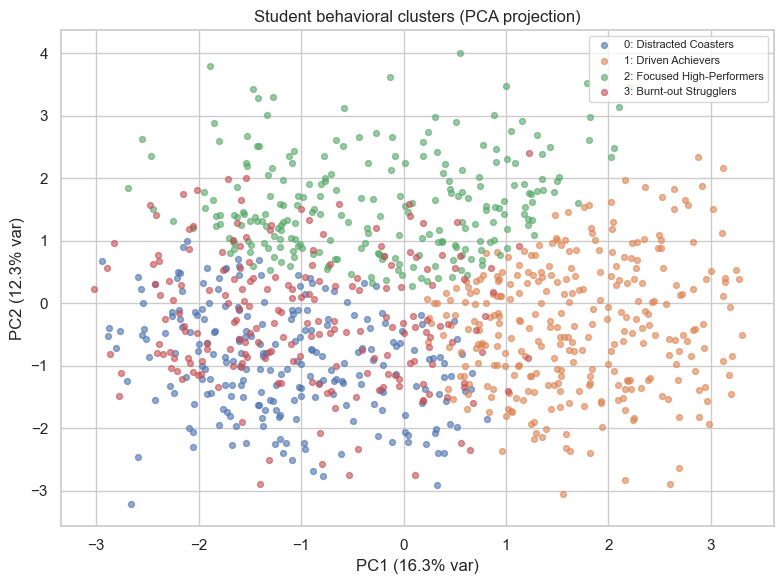

In [7]:
clusterer.plot_pca_scatter(config.PLOTS_DIR / "clustering_pca_scatter.png");

Quick check that a single-student prediction works the way the API will
call it, then we save the fitted clusterer and its scaler

In [8]:
sample = features.iloc[0].to_dict()
print(clusterer.predict_cluster(sample))

clusterer.save()

{'cluster_id': 2, 'cluster_name': 'Focused High-Performers', 'cluster_description': 'Highest study hours, focus, productivity, and revision with low distraction. Intense, diligent workers.', 'nearest_centroid_distance': 4.0908}


## Key takeaways

- Silhouette is weak and favours k=2; the structure is essentially one
  effort/consistency axis. I went with k=4 for actionable personas and said so
  plainly rather than pretending the metric chose it.
- The four profiles are genuinely distinct on the z-scored centres: organised
  achievers, heads-down high-performers, relaxed coasters, and burnt-out
  strugglers.
- Scaler and centroids are fit on the training split only, and the model plus
  scaler are saved for the inference pipeline.